# Diabestes Prediction 

## content
  1. Introduction
  2. Load & Inspect the Dataset
  3. Data Cleaning
  4. Univariate Analysis
  5. Bivariate Analysis
  6. Multivariate Analysis



 

##  01. Introduction

`This project aims to analyze how different health-related factors influence the likelihood of diabetes.`

## 02. Load & Inspect the Dataset

### 2.1 Data Collection

- I used the Diabetes dataset, which I downloaded from the Hugging Face platform. 
- Data Source: - 

### 2.3 Load dataset

In [9]:
# import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Set the style and color palette for seaborn
sns.set_style('whitegrid')
color_palette = sns.color_palette("crest")

In [10]:
# Load the dataset
from pathlib import Path

data_path = Path('../data/diabetes_prediction_dataset.csv')
if not data_path.exists():
    data_path = Path('data/diabetes_prediction_dataset.csv')

df = pd.read_csv(data_path)
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [11]:
df.gender.value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [12]:
# Shape of the dataset
df.shape

(100000, 9)

In [13]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [14]:
# Statistical summary of the dataset
print("Statistical summary of the dataset:")
print(df.describe().T)
print("\nStatistical summary of the categorical features:")
print(df.describe(include='object').T)

Statistical summary of the dataset:
                        count        mean        std    min     25%     50%  \
age                  100000.0   41.885856  22.516840   0.08   24.00   43.00   
hypertension         100000.0    0.074850   0.263150   0.00    0.00    0.00   
heart_disease        100000.0    0.039420   0.194593   0.00    0.00    0.00   
bmi                  100000.0   27.320767   6.636783  10.01   23.63   27.32   
HbA1c_level          100000.0    5.527507   1.070672   3.50    4.80    5.80   
blood_glucose_level  100000.0  138.058060  40.708136  80.00  100.00  140.00   
diabetes             100000.0    0.085000   0.278883   0.00    0.00    0.00   

                        75%     max  
age                   60.00   80.00  
hypertension           0.00    1.00  
heart_disease          0.00    1.00  
bmi                   29.58   95.69  
HbA1c_level            6.20    9.00  
blood_glucose_level  159.00  300.00  
diabetes               0.00    1.00  

Statistical summary of the

### 2.3 Dataset information


- **Variables**
    - Gender: -  Sex of a Human `(Male, Female, Other )`
    - Age: - Age of a Human `(8d - 60y)`
    - hypertension: - indicates the presence of high blood pressure `(0 - 1)`
    - heart_disease: - indicate whether a person has heart disease or not `( 0:No, 1: Yes)`
    - smoking_history:- indicate the smoking history of an individual  `(never,former,current ,not current,ever,No Info)`
    - bmi:- Body Mass Index of an individual, which is a measure of body fat based on height and weight `(10. - 95.69)`
    - HbA1c_level:- Represents the glycated hemoglobin level, which indicates average blood sugar level. `(3.50 - 9.0)`
    - blood_glucose_level: - Current blood sugar level of the individual, usually measured in mg/dL `(80.0- 300)`
    - diabetes: - Target variable indicating whether the individual has diabetes `(1: Yes, 0: No)`.
    


## 03. Data Cleaning

In [15]:
# Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


- There are no any missing values in this dataset

In [16]:
# Duplicate values in the dataset
print("Number of duplicate rows in the dataset:", df.duplicated().sum())


Number of duplicate rows in the dataset: 3854


- There are 3,854 duplicated values in this dataset, but I kept them because in this problem, some individuals may have identical records.

In smoking history, there are 6 unique values,
  1. No Info
  2. never
  3. former
  4. current
  5. not current
  6. ever
    
There are fields called former and not current which are similar. We can combine them into one category called "former".

In [17]:
df['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [18]:
df['smoking_history'] = df['smoking_history'].replace({'not current': 'former'})
df['smoking_history'].value_counts()

smoking_history
No Info    35816
never      35095
former     15799
current     9286
ever        4004
Name: count, dtype: int64

## 04. Univariate Analysis

Function for Count Outliers

In [19]:
def cal_outliers(column: str) -> int:
    ''' 
    Function to calculate outliers in a given column using the IQR method.
    Parameters:
    column (str): The name of the column for which to calculate outliers.
    Returns:
    int: The number of outliers in the specified column.
    '''
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].count()[column]
    return outliers

#### 4.1 Diabetes - Target variable

Values of the target variable (diabetes):
diabetes
No Diabetes    91500
Diabetes        8500
Name: count, dtype: int64 



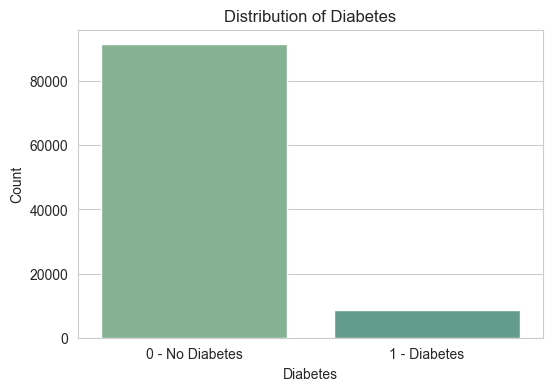

In [20]:
# Values of the target variable

print("Values of the target variable (diabetes):")
print(df['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'}).value_counts(), "\n") 


# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(
    x=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}),
    order=['0 - No Diabetes', '1 - Diabetes'],
    palette=color_palette
)
plt.title('Distribution of Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

There are,
   - 8500 persons has Diabetes
   - 91500 has not 

#### 4.2 Gender Variable

Values of the Gender variable:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64 



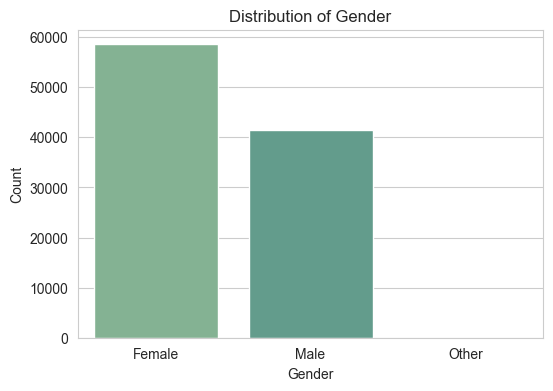

In [21]:
# Values of the Gender variable
print("Values of the Gender variable:")
print(df['gender'].value_counts(), "\n")

# Visualize the distribution of the
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette=color_palette)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

There are,
   - 58552 Female
   - 41430 male
   - 18 of Other gender

#### 4.3 Age Variable

Summary statistics of the Age variable:
count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64 



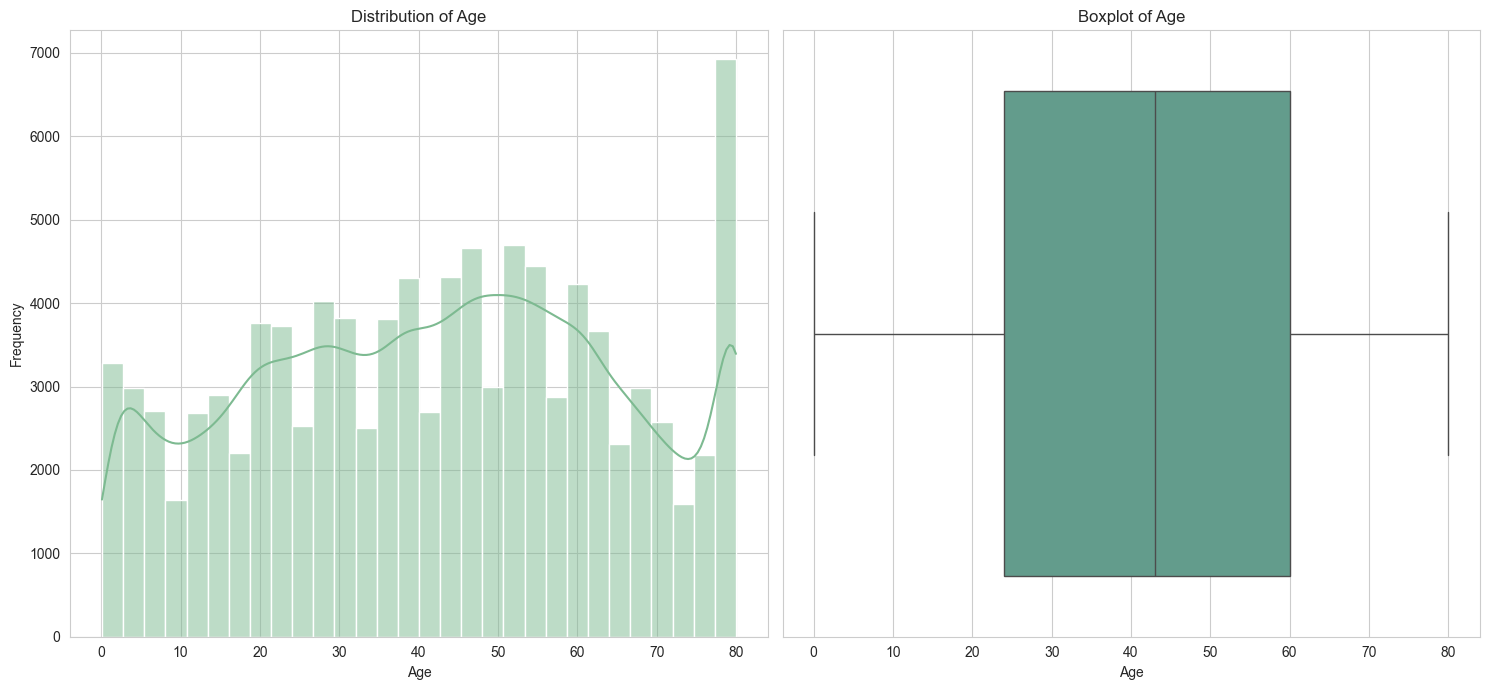

In [22]:
# Summery statistics of the Age variable

print("Summary statistics of the Age variable:")
print(df['age'].describe(), "\n")
# Visualize the distribution of the Age variable

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(df['age'], bins=30, kde=True, color=color_palette[0], ax=ax[0])
ax[0].set_title('Distribution of Age')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Frequency')
sns.boxplot(x=df['age'], color=color_palette[1], ax=ax[1])
ax[1].set_title('Boxplot of Age')
ax[1].set_xlabel('Age')
plt.tight_layout()
plt.show()



In [23]:
# Outliers in the Age variable
age_outliers = cal_outliers('age')
print(f"Number of outliers in the Age variable: {age_outliers}")


Number of outliers in the Age variable: 0


#### 4.3 hypertension Variable

Values of the hypertension variable:
hypertension
No Hypertension    92515
Hypertension        7485
Name: count, dtype: int64 



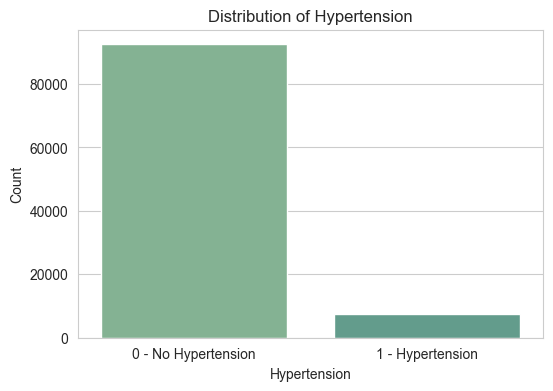

In [24]:
# Values of the hypertension variable
print("Values of the hypertension variable:")
print(df['hypertension'].map({0: 'No Hypertension', 1: 'Hypertension'}).value_counts(), "\n")

# Visualize the distribution of the hypertension variable
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x=df['hypertension'].map({0: '0 - No Hypertension', 1: '1 - Hypertension'}),
    order=['0 - No Hypertension', '1 - Hypertension'],
    palette=color_palette,
    
)
plt.title('Distribution of Hypertension')
plt.xlabel('Hypertension')
plt.ylabel('Count')
plt.show()


#### 4.4 heart_disease Variable

Values of the heart_disease variable:
heart_disease
No Heart Disease    96058
Heart Disease        3942
Name: count, dtype: int64 



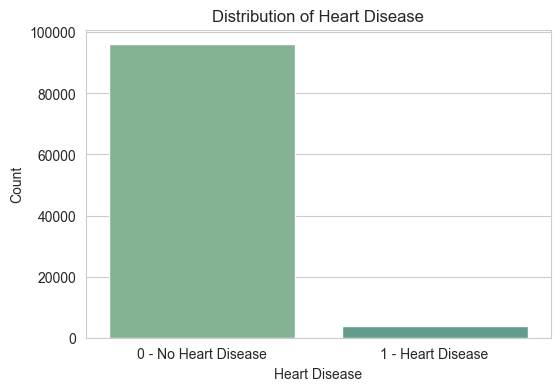

In [25]:
# Values of the Heart Disease variable
print("Values of the heart_disease variable:")
print(df['heart_disease'].map({0: 'No Heart Disease', 1: 'Heart Disease'}).value_counts(), "\n")

# Visualize the distribution of the heart_disease variable
plt.figure(figsize=(6, 4))
sns.countplot(
    x=df['heart_disease'].map({0: '0 - No Heart Disease', 1: '1 - Heart Disease'}),
    order=['0 - No Heart Disease', '1 - Heart Disease'],
    palette=color_palette
)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()


#### 4.5 smoking_history Variable

Values of the smoking_history variable:
smoking_history
No Info    35816
never      35095
former     15799
current     9286
ever        4004
Name: count, dtype: int64 



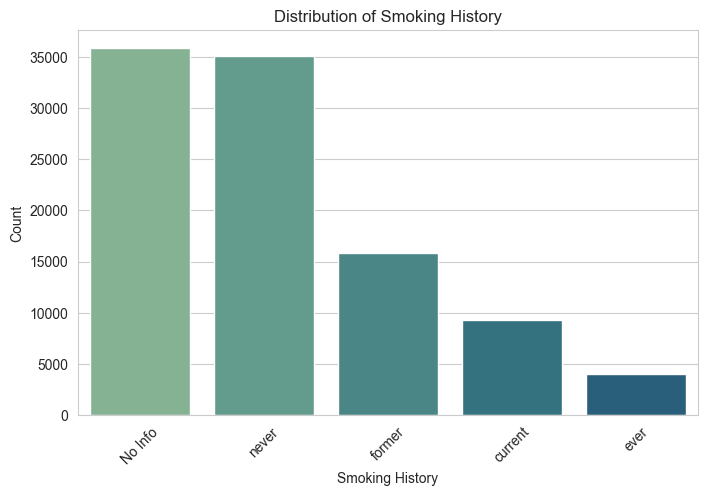

In [26]:
# Values of the smoking_history variable
print("Values of the smoking_history variable:")   
print(df['smoking_history'].value_counts(), "\n")

# Visualize the distribution of the smoking_history variable
plt.figure(figsize=(8, 5))
sns.countplot(x='smoking_history', data=df, order=df['smoking_history'].value_counts().index, palette=color_palette)
plt.title('Distribution of Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


#### 4.6 bmi Variable

Statistical summary of the BMI variable:
count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max          95.690000
Name: bmi, dtype: float64


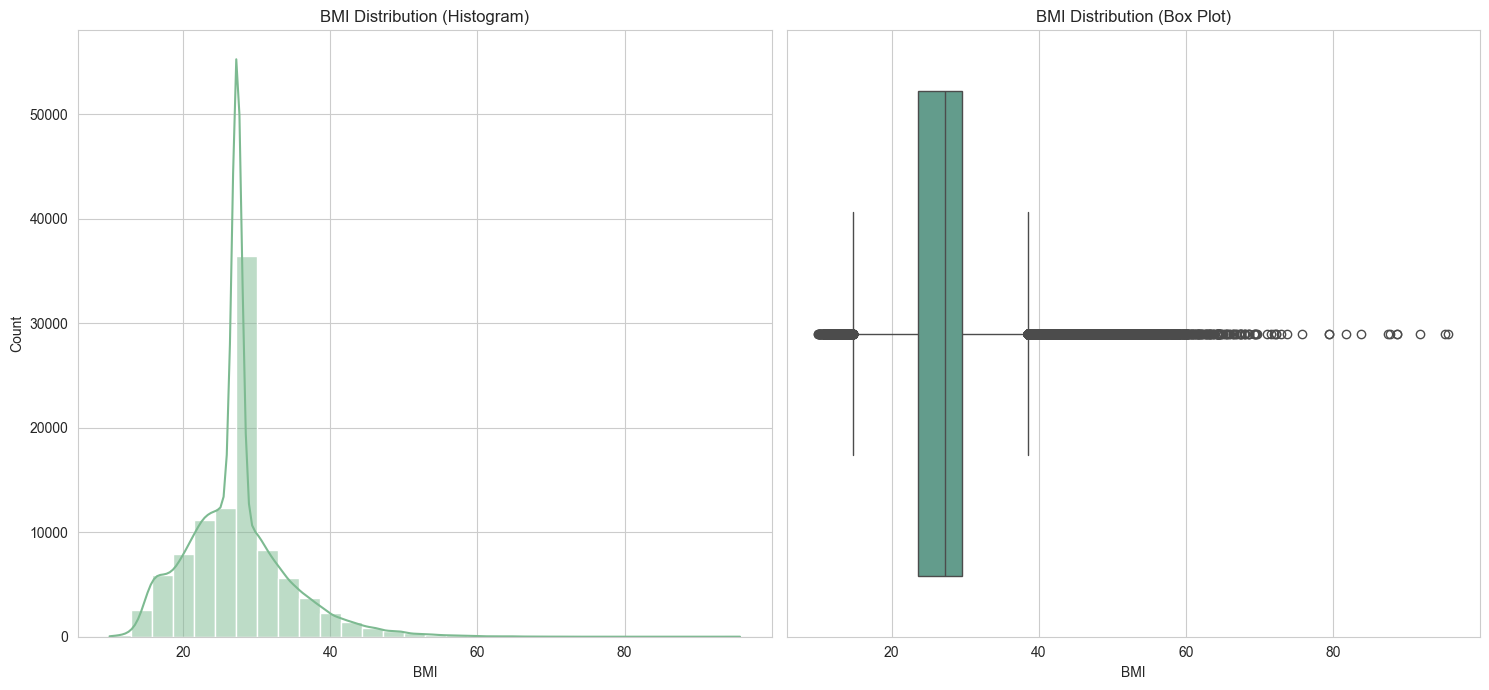

In [27]:
print("Statistical summary of the BMI variable:")
print(df['bmi'].describe())

# Visualize the distribution of the BMI variable using histogram and box plot
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df, x='bmi',bins=30, kde=True, color=color_palette[0], ax=ax[0])
ax[0].set_title('BMI Distribution (Histogram)')
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Count')

sns.boxplot(data=df, x='bmi', color=color_palette[1], ax=ax[1])
ax[1].set_title('BMI Distribution (Box Plot)')
ax[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()


In [28]:
# Outliers in the BMI variable
bmi_outliers = cal_outliers('bmi')
print(f"Number of outliers in the BMI variable: {bmi_outliers}")

Number of outliers in the BMI variable: 7086


- There are some outliers in the BMI variable, as indicated by the box plot. The histogram also shows a right-skewed distribution, which may be influenced by these outliers. 

- There are 7086 outliers

#### 4.7 HbA1c_level Variable

Statistical summary of the HbA1c_level variable:
count    100000.000000
mean          5.527507
std           1.070672
min           3.500000
25%           4.800000
50%           5.800000
75%           6.200000
max           9.000000
Name: HbA1c_level, dtype: float64


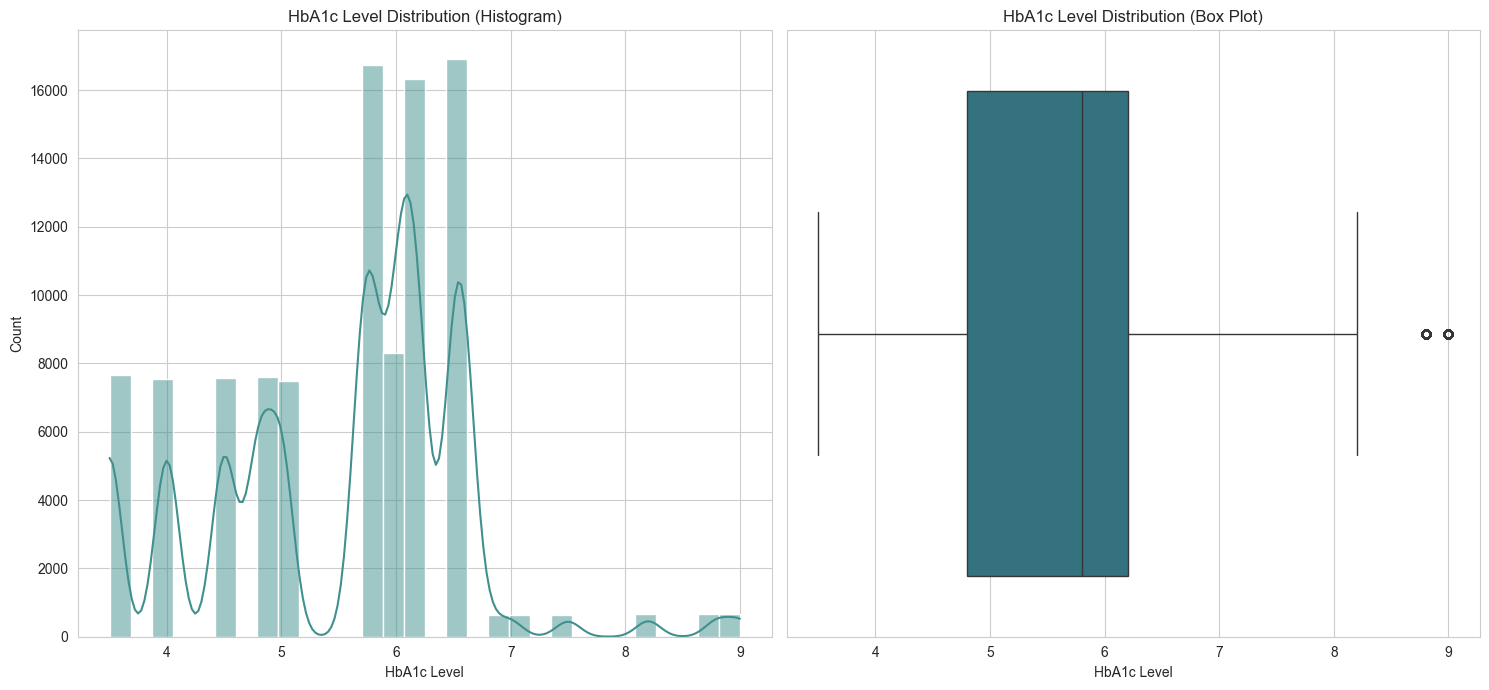

In [29]:
# Statistical summary of the HbA1c_level variable:

print("Statistical summary of the HbA1c_level variable:")
print(df['HbA1c_level'].describe().T)

# Visualize the distribution of the HbA1c_level variable using histogram and box plot
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='HbA1c_level', bins=30, kde=True, color=color_palette[2], ax=ax[0])
ax[0].set_title('HbA1c Level Distribution (Histogram)')
ax[0].set_xlabel('HbA1c Level')
ax[0].set_ylabel('Count')
sns.boxplot(data=df, x='HbA1c_level', color=color_palette[3], ax=ax[1])
ax[1].set_title('HbA1c Level Distribution (Box Plot)')
ax[1].set_xlabel('HbA1c Level')
plt.tight_layout()
plt.show()


In [30]:
outliers_hba1c = cal_outliers('HbA1c_level')
print(f"Number of outliers in the HbA1c_level variable: {outliers_hba1c}")

Number of outliers in the HbA1c_level variable: 1315


- HbA1c levels are centered around 6, with a relatively narrow spread.
- There are 1315 outliers

#### 4.8 blood_glucose_level

Statistical summary of the blood_glucose_level variable:
count    100000.000000
mean        138.058060
std          40.708136
min          80.000000
25%         100.000000
50%         140.000000
75%         159.000000
max         300.000000
Name: blood_glucose_level, dtype: float64


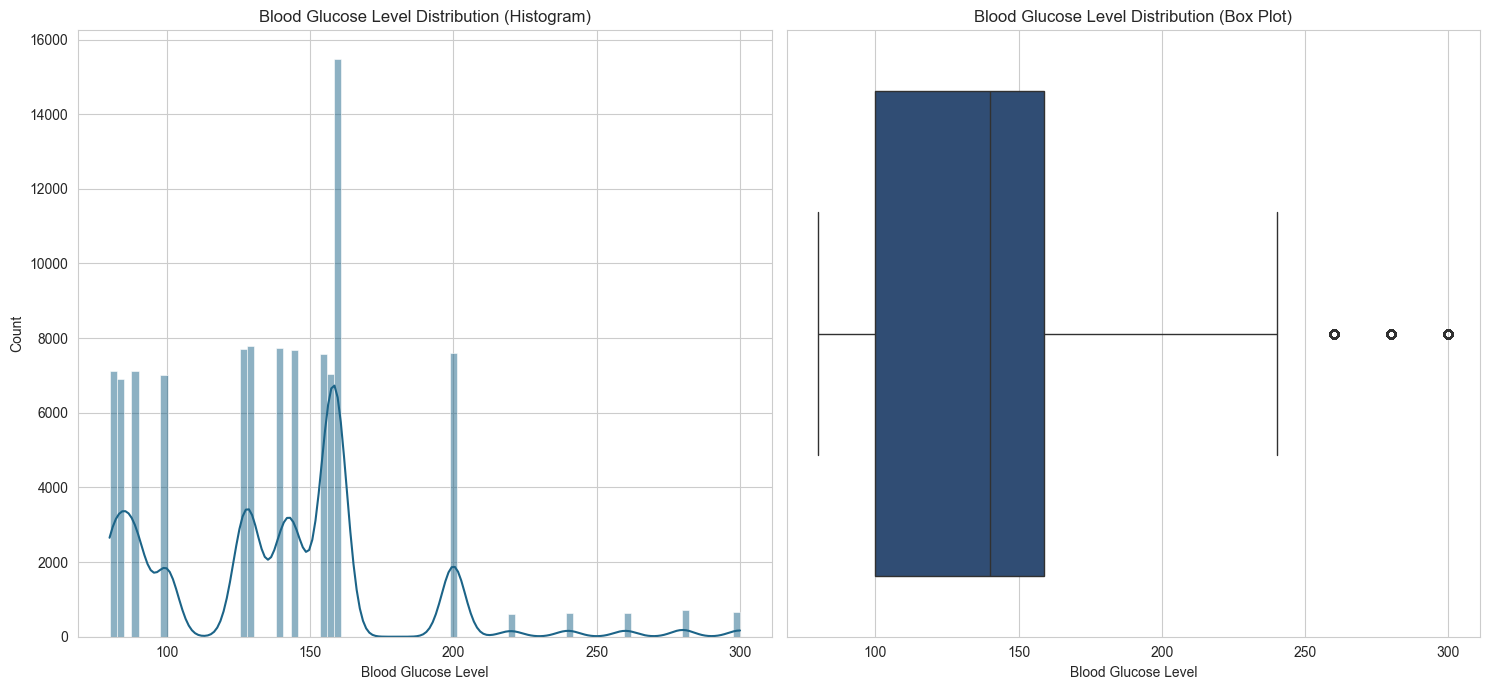

In [31]:
# Summary statistics of the blood_glucose_level variable
print("Statistical summary of the blood_glucose_level variable:")
print(df['blood_glucose_level'].describe().T)

# Visualize the distribution of the blood_glucose_level variable using histogram and box plot
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='blood_glucose_level',  kde=True, color=color_palette[4], ax=ax[0])
ax[0].set_title('Blood Glucose Level Distribution (Histogram)')
ax[0].set_xlabel('Blood Glucose Level')
ax[0].set_ylabel('Count')
sns.boxplot(data=df, x='blood_glucose_level', color=color_palette[5], ax=ax[1])
ax[1].set_title('Blood Glucose Level Distribution (Box Plot)')
ax[1].set_xlabel('Blood Glucose Level')
plt.tight_layout()
plt.show()


In [32]:
outliers_blood_glucose = cal_outliers('blood_glucose_level')
print(f"Number of outliers in the blood_glucose_level variable: {outliers_blood_glucose}")

Number of outliers in the blood_glucose_level variable: 2038


we can see that the plot skewed to the left and there are some outliers in the blood_glucose_level variable.

## 05. Bivariate Analysis

- Target variable is `Diabetes`,
- So analyze each variable with Diabetes

#### 5.1 Diabetes vs Age

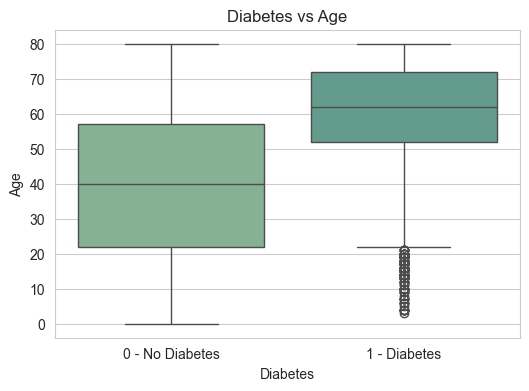

In [33]:
# Diabetes vs Age 
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}), y='age', data=df, palette=color_palette)
plt.title('Diabetes vs Age')
plt.xlabel('Diabetes')
plt.ylabel('Age')
plt.show()


Based on the box plot, we can observe that the median age of individuals with diabetes is higher than those without diabetes. Additionally, there are more outliers in the age variable for individuals with diabetes compared to those without diabetes. This suggests that age may be a significant factor in diabetes prediction, and `older individuals may be at a higher risk of developing diabetes.`

#### 5.2 Diabetes  vs gender

Values of the gender variable grouped by diabetes status:
diabetes  gender
0         Female    54091
          Male      37391
          Other        18
1         Female     4461
          Male       4039
Name: count, dtype: int64 



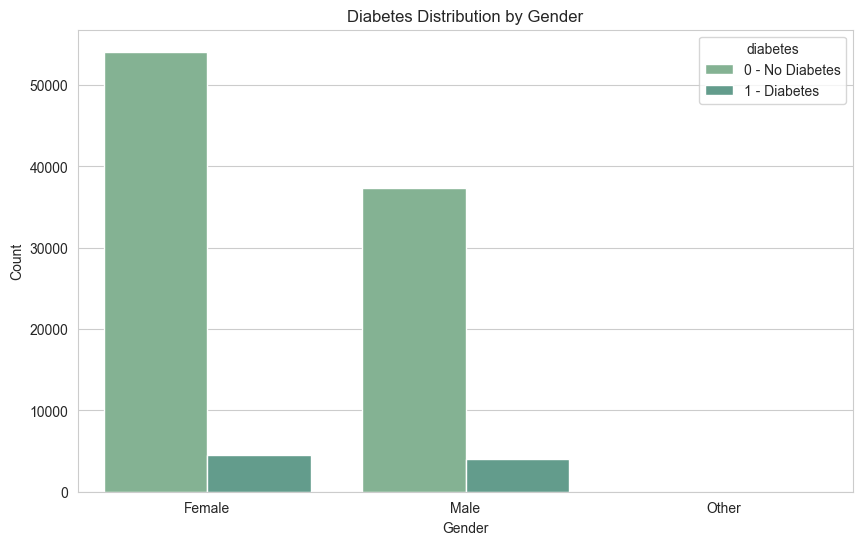

In [34]:
# Diabetes vs BMI
print('Values of the gender variable grouped by diabetes status:')
print(df['gender'].groupby(df['diabetes']).value_counts(), "\n")

# Visualize the distribution of diabetes across different genders
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=df, hue=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}), palette=color_palette)
plt.title('Diabetes Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Based on this observation, we can see that diabetes is more prevalent in males than females in this dataset.

#### 5.3 hypertension Vs diabetes

Values of the diabetes variable group by hypertension status:
hypertension     diabetes
Hypertension     No           5397
                 Yes          2088
No Hypertension  No          86103
                 Yes          6412
Name: count, dtype: int64




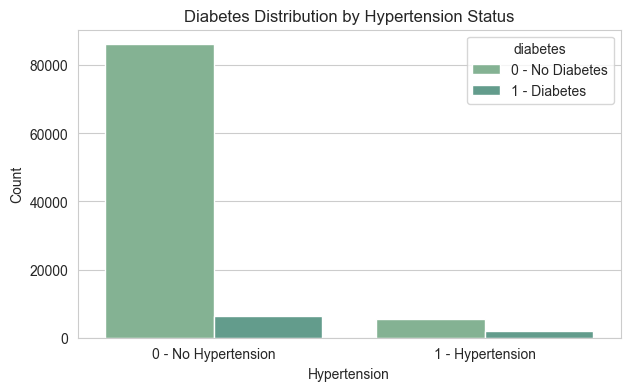

In [35]:
# Value count of the variable
print("Values of the diabetes variable group by hypertension status:")
print(df["diabetes"].map({0: "No", 1: "Yes"}).groupby(df["hypertension"].map({0: "No Hypertension", 1: "Hypertension"})).value_counts())
print("\n")


# Visualize the distribution of diabetes across hypertension status
plt.figure(figsize=(7, 4))
sns.countplot(x=df['hypertension'].map({0: '0 - No Hypertension', 1: '1 - Hypertension'}), hue=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}), palette=color_palette)
plt.title('Diabetes Distribution by Hypertension Status')
plt.xlabel('Hypertension')
plt.ylabel('Count')
plt.show()


Further analysis of hypertension Vs diabetes

Mean of diabetes variable grouped by hypertension status:
0     6.930768
1    27.895792
Name: diabetes, dtype: float64


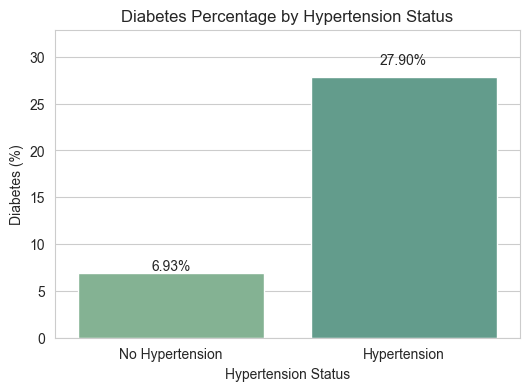

Risk of diabetes in hypertensive patients compared to non-hypertensive patients: 4.02 times higher


In [36]:
# The bar chart not clearly shows the relationship between diabetes and heart disease.
# So I do I by getting mean of the data

hyp_diabetes = (
    df.groupby('hypertension')['diabetes']
        .mean()
        .reset_index()
        .replace({"hypertension": {0: "No Hypertension", 1: "Hypertension"}}))


print("Mean of diabetes variable grouped by hypertension status:")
hyp_diabetes['diabetes'] = hyp_diabetes['diabetes'] * 100 # Convert to persentage
print(hyp_diabetes['diabetes'])

# Visualize the relationship between diabetes and hypertension using a bar chart
plt.figure(figsize=(6,4))
ax = sns.barplot(data=hyp_diabetes, x='hypertension', y='diabetes', palette=color_palette)
plt.title("Diabetes Percentage by Hypertension Status")
plt.xlabel("Hypertension Status")
plt.ylabel("Diabetes (%)")

for i,v in enumerate(hyp_diabetes['diabetes']):
    ax.text(i,v+i, f"{v:.2f}%", ha='center', va='bottom')

plt.ylim(0,hyp_diabetes['diabetes'].max() + 5 )
plt.show()

# Risk of diabetes in hypertensive patients compared to non-hypertensive patients
risk_ratio = hyp_diabetes.iloc[1, 1] / hyp_diabetes.iloc[0, 1]
print(f"Risk of diabetes in hypertensive patients compared to non-hypertensive patients: {risk_ratio:.2f} times higher")

People with hypertension show a substantially higher diabetes rate than people without hypertension.
In this dataset, diabetes prevalence is much higher in the hypertension group, and the risk is about risk_ratio 4x times greater.
This indicates a strong association.

#### 5.4 diabetes vs heart_disease

Mean of diabetes variable grouped by heart disease status:


0     7.529826
1    32.141045
Name: diabetes, dtype: float64


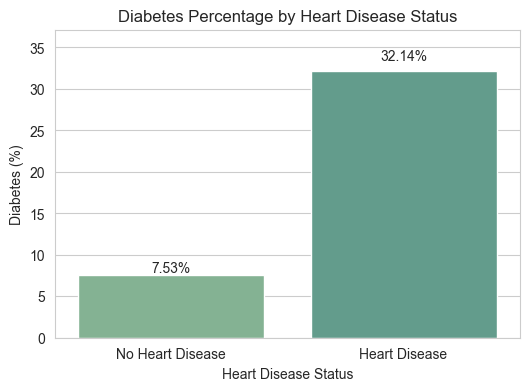

Risk of diabetes in patients with heart disease compared to those without heart disease: 4.27 times higher


In [37]:
heart_dia = (
    df.groupby('heart_disease')['diabetes']
      .mean()
      .mul(100)
      .reset_index()
      .replace({"heart_disease": {0: "No Heart Disease", 1: "Heart Disease"}})
)

print("Mean of diabetes variable grouped by heart disease status:")
print(heart_dia['diabetes'])



# Visualize the relationship between diabetes and heart disease using a bar chart
plt.figure(figsize=(6,4))
ax = sns.barplot(data=heart_dia, x='heart_disease', y='diabetes', palette=color_palette)
plt.title("Diabetes Percentage by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Diabetes (%)")
for i,v in enumerate(heart_dia['diabetes']):
    ax.text(i,v+i, f"{v:.2f}%", ha='center', va='bottom')
plt.ylim(0, heart_dia['diabetes'].max() + 5)
plt.show()


# Risk of diabetes in patients with heart disease compared to those without heart disease
risk_ratio_heart = heart_dia.iloc[1, 1] / heart_dia.iloc[0, 1]
print(f"Risk of diabetes in patients with heart disease compared to those without heart disease: {risk_ratio_heart:.2f} times higher")





From this analysis, people with Heart Diseases have higher chance to Develop Diabetes than none heart disease persons. 

#### 5.5 diabetes vs smoking history

Mean of diabetes variable grouped by smoking history:
  smoking_history   diabetes
0         No Info   4.059638
1         current  10.208917
2            ever  11.788212
3          former  14.431293
4           never   9.534122


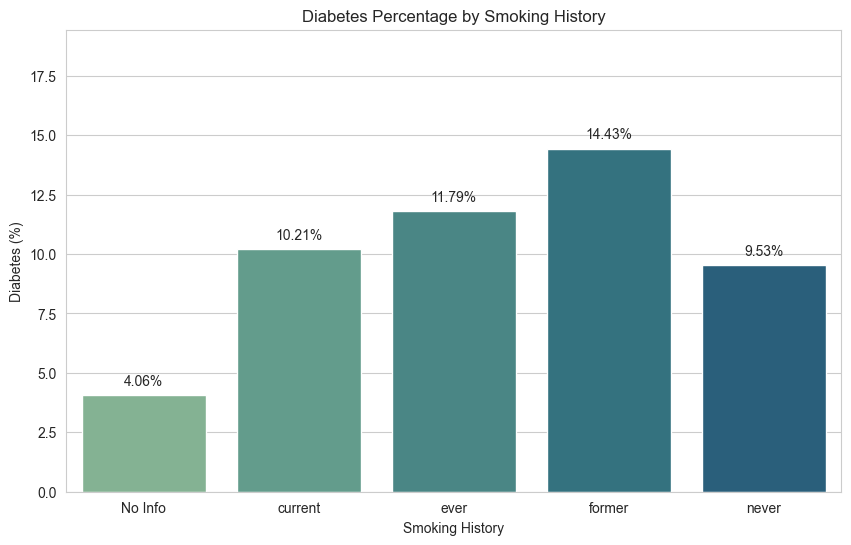

In [38]:
sh_dia = (
    df.groupby('smoking_history')['diabetes']
      .mean()
      .mul(100)
      .reset_index()

)

print("Mean of diabetes variable grouped by smoking history:")
print(sh_dia)

# Visualize the relationship between diabetes and smoking history using a bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sh_dia, x='smoking_history', y='diabetes', palette=color_palette)
plt.title("Diabetes Percentage by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Diabetes (%)")
for i,v in enumerate(sh_dia):
    if i == 0:
      for p in ax.patches:
        h = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, h + 0.3, f"{h:.2f}%", ha='center', va='bottom')
      break
plt.ylim(0, sh_dia['diabetes'].max() + 5)
plt.show()

Individuals who smoke before have diabets than the Others. its 14.43%

#### 5.6 BMI vs Diabetes

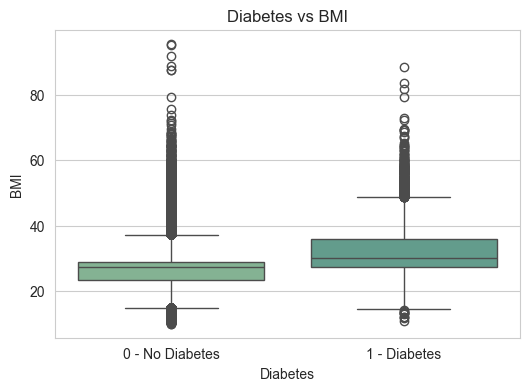

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}), y='bmi', data=df, palette=color_palette)
plt.title('Diabetes vs BMI')
plt.xlabel('Diabetes')
plt.ylabel('BMI')
plt.show()

BMI value is higher in Diabetes persons than none diabetes persons

#### 5.7 HbA1c_level vs Diabetes


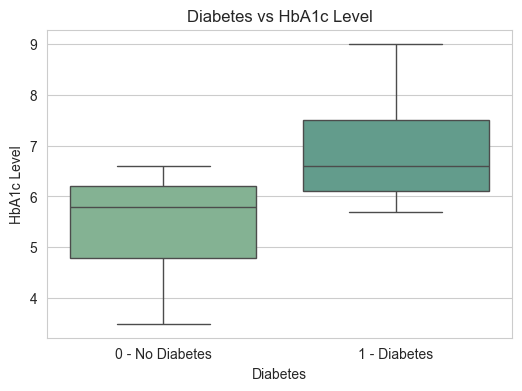

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}), y='HbA1c_level', data=df, palette=color_palette)
plt.title('Diabetes vs HbA1c Level')
plt.xlabel('Diabetes')
plt.ylabel('HbA1c Level')
plt.show()


#### 5.8 blood_glucose_level vs Diabets

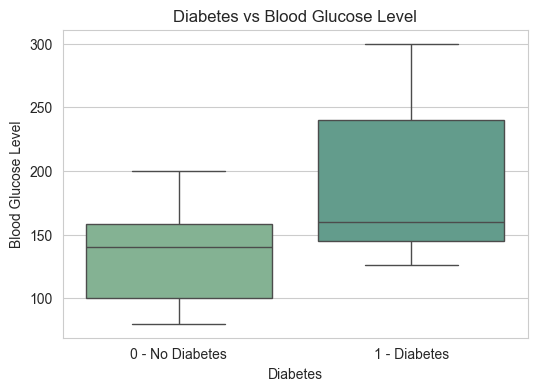

In [41]:
# Visualize the relationship between diabetes and blood glucose level using a box plot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['diabetes'].map({0: '0 - No Diabetes', 1: '1 - Diabetes'}), y='blood_glucose_level', data=df, palette=color_palette)
plt.title('Diabetes vs Blood Glucose Level')
plt.xlabel('Diabetes')
plt.ylabel('Blood Glucose Level')
plt.show()


In this dataset, higher blood glucose levels are strongly associated with diabetes. Individuals in the 150–200+ mg/dL range appear more frequently in the diabetes group than in the non-diabetes group.

## 06. Multivariate Analysis

#### Correlation Analysis

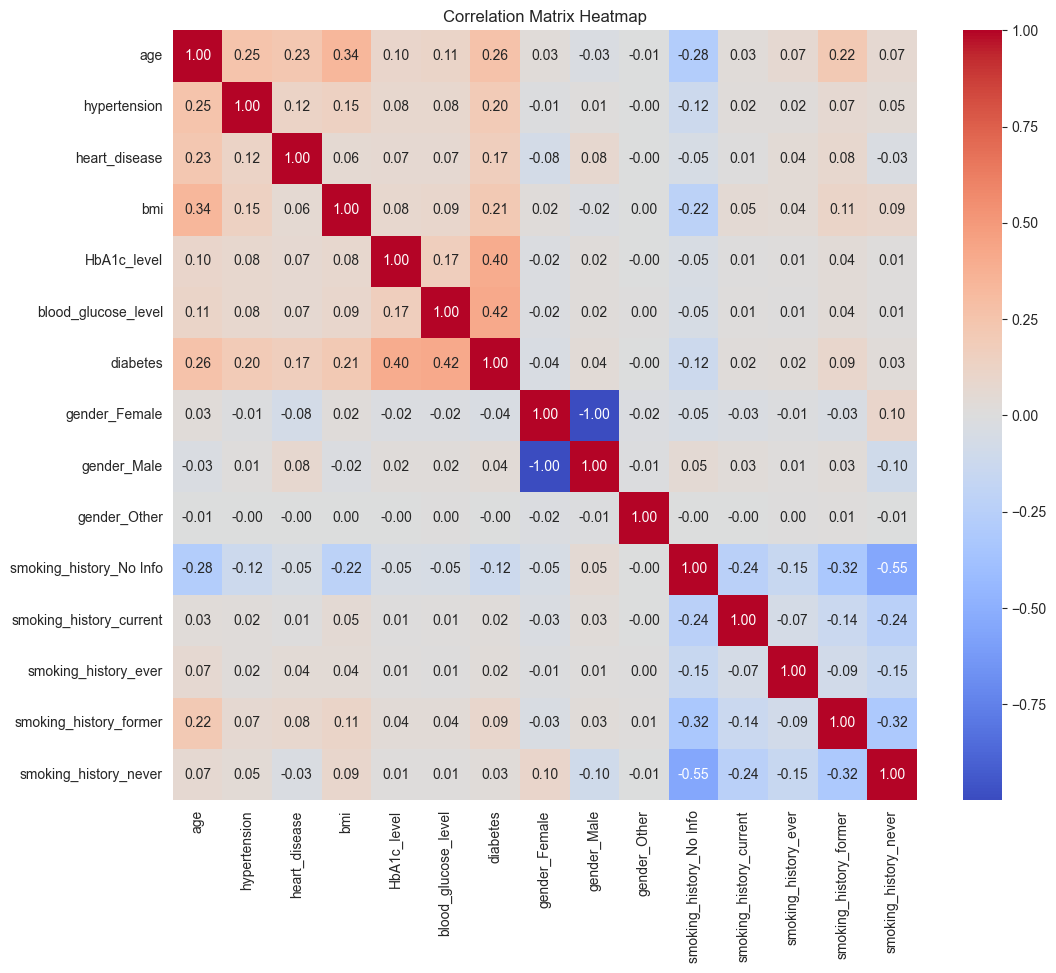

In [42]:
# Convert cat features to numerical values for correlation analysis
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=['gender', 'smoking_history'])
# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

- Based on the **heatmap**, **HbA1c_level** and **blood_glucose_level** show the strongest positive correlation with the target variable (**diabetes**) (moderate correlation).
- **age**, **bmi**, **hypertension**, and **heart_disease** also have positive correlations with diabetes, but they are weaker.
- **Gender** and most **smoking history** categories show weak (near-zero) correlation with diabetes.

## EDA Summary

### Data Overview
- Loaded the diabetes prediction dataset and inspected shape, data types, and descriptive statistics.
- Checked data quality:
  - No missing values were found.
  - 3,854 duplicate rows were found and retained.
- Cleaned `smoking_history` by merging **`not current`** into **`former`**.

### Univariate Analysis
- The target variable is imbalanced:
  - **Diabetes (1): ~8,500**
  - **No Diabetes (0): ~91,500**
- Explored distributions of `age`, `bmi`, `HbA1c_level`, and `blood_glucose_level`.
- Outliers were identified, especially in `bmi`, `HbA1c_level`, and `blood_glucose_level`.

### Bivariate Analysis (with Diabetes)
- People with diabetes generally show higher:
  - `age`
  - `bmi`
  - `HbA1c_level`
  - `blood_glucose_level`
- Diabetes prevalence is higher among individuals with:
  - `hypertension`
  - `heart_disease`
- Gender and smoking history show visible group differences, but weaker patterns compared with glucose-related features.

### Multivariate Analysis (Correlation Heatmap)
- Strongest positive correlations with `diabetes`:
  - `blood_glucose_level` (~0.42)
  - `HbA1c_level` (~0.40)
- Weak-to-moderate positive correlations:
  - `age` (~0.26), `bmi` (~0.21), `hypertension` (~0.20), `heart_disease` (~0.17)
- `gender` and most `smoking_history` dummy variables have weak (near-zero) linear correlation with diabetes.

### Final Insight
- In this dataset, diabetes is most strongly associated with **blood glucose** and **HbA1c** levels, followed by **age**, **BMI**, **hypertension**, and **heart disease**.
- These findings indicate association, not causation.

In [48]:
# Save the cleaned dataset to a new CSV file
from pathlib import Path

output_path = Path('../data/diabetes_prediction_dataset_cleaned.csv')
if not output_path.parent.exists():
    output_path = Path('data/diabetes_prediction_dataset_cleaned.csv')

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f'Saved cleaned dataset to: {output_path.resolve()}')

Saved cleaned dataset to: D:\Data Science\Projects\Ongoing\Diabetes-Prediction-ML\data\diabetes_prediction_dataset_cleaned.csv
